In [1]:
from datasets.fsmol_dock import FsDockDataset
from datasets.partitioned_fsmol_dock import FsDockDatasetPartitioned
import torch
from Bio.PDB import PDBParser, DSSP, PPBuilder
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import numpy as np
import os
import pandas as pd
from collections import defaultdict
import freesasa

/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [ ]:
assays = ['CHEMBL1119333',
 'CHEMBL1614027',
 'CHEMBL1614423',
 'CHEMBL1963715',
'CHEMBL1738485',
 'CHEMBL1963723',
 'CHEMBL1963731',
 'CHEMBL1963741',
 'CHEMBL1963756',
 'CHEMBL1963810',
 'CHEMBL1963818',
 'CHEMBL1963819',
 'CHEMBL1963824',
 'CHEMBL1963825',
 'CHEMBL1963827',
 'CHEMBL1963831',
 'CHEMBL1964101',
 'CHEMBL1964115',
 'CHEMBL3214944',
 'CHEMBL3431930',
 'CHEMBL3431932']

tasks = pd.read_csv('/home/alon.kitin/fs-dock/data/fsdock/test_tasks.csv')
tasks = tasks[tasks['assay_id'].isin(assays)]

train_features = pd.read_csv('/home/alon.kitin/fs-dock/data/fsdock/train_features.csv')

In [8]:
s = '''
CHEMBL1119333	0.338
CHEMBL1614027	0.274
CHEMBL1614423	0.149
CHEMBL1738485	0.147
CHEMBL1963715	0.090
CHEMBL1963723	0.291
CHEMBL1963731	0.238
CHEMBL1963741	0.103
CHEMBL1963756	0.120
CHEMBL1963810	0.104
CHEMBL1963818	0.474
CHEMBL1963819	0.097
CHEMBL1963824	0.104
CHEMBL1963825	0.267
CHEMBL1963827	0.137
CHEMBL1963831	0.324
CHEMBL1964101	0.271
CHEMBL1964115	0.418
CHEMBL3214944	0.352
CHEMBL3431930	0.173
CHEMBL3431932	0.066
'''.strip().split('\n')
success = dict()
for l in s:
    l = l.split('\t')
    success[l[0]] = float(l[1])

In [9]:
pdb_files = tasks[['assay_id','protein_path']].drop_duplicates()

In [10]:
def extract_features_from_pdb(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    model = structure[0]

    # Extract sequence
    ppb = PPBuilder()
    sequence = "".join([str(pp.get_sequence()) for pp in ppb.build_peptides(model)])
    analysis = ProteinAnalysis(sequence)

    # General sequence features
    features = {}
    features["length"] = len(sequence)
    features["molecular_weight"] = analysis.molecular_weight()
    features["aromaticity"] = analysis.aromaticity()
    features["instability_index"] = analysis.instability_index()
    features["isoelectric_point"] = analysis.isoelectric_point()
    features["gravy"] = analysis.gravy()

    # Amino acid composition
    aa_composition = analysis.get_amino_acids_percent()
    for aa, perc in aa_composition.items():
        features[f"aa_{aa}"] = perc
    freesasa_struct = freesasa.Structure(pdb_file)
    features['sasa'] = freesasa.calc(freesasa_struct).totalArea()
    
    # DSSP for secondary structure content
    # try:
    #     dssp = DSSP(model, pdb_file)
    #     ss_counts = {"H": 0, "B": 0, "E": 0, "G": 0, "I": 0, "T": 0, "S": 0, "-": 0}
    #     for _, dssp_data in dssp.property_list:
    #         ss = dssp_data[2]
    #         ss_counts[ss] = ss_counts.get(ss, 0) + 1

    #     total_residues = sum(ss_counts.values())
    #     features["helix_content"] = (ss_counts["H"] + ss_counts["G"] + ss_counts["I"]) / total_residues
    #     features["sheet_content"] = (ss_counts["E"] + ss_counts["B"]) / total_residues
    #     features["coil_content"] = (ss_counts["T"] + ss_counts["S"] + ss_counts["-"]) / total_residues
    # except Exception as e:
    #     print("DSSP failed:", e)

    # # Ligand-binding site: count of residues within 5 Å of ligand atoms
    # ligand_atoms = [atom for atom in model.get_atoms() if atom.get_parent().id[0].startswith("H_")]
    # binding_residues = set()
    # for chain in model:
    #     for residue in chain:
    #         if residue.id[0] == " ":
    #             for atom in residue:
    #                 for ligand_atom in ligand_atoms:
    #                     distance = atom - ligand_atom
    #                     if distance < 5.0:
    #                         binding_residues.add(residue)
    #                         break
    # features["binding_site_residue_count"] = len(binding_residues)

    return features

In [11]:
features = {}
for task in pdb_files.iterrows():
    task= task[1]
    features[task['assay_id']] = extract_features_from_pdb(task['protein_path'])
    features[task['assay_id']]['label'] = success[task['assay_id']]
features_df = pd.DataFrame.from_dict(features, orient='index')

In [12]:
np.array(features_df['label'])

array([0.338, 0.274, 0.149, 0.147, 0.09 , 0.291, 0.238, 0.103, 0.12 ,
       0.104, 0.474, 0.097, 0.104, 0.267, 0.137, 0.324, 0.271, 0.418,
       0.352, 0.173, 0.066])

In [13]:
features_df.corr()['label'].abs().sort_values(ascending=False)

label                1.000000
aa_T                 0.575713
aa_I                 0.560154
aa_D                 0.545570
aa_M                 0.457687
aa_G                 0.425564
aa_P                 0.419380
aa_N                 0.376646
aa_K                 0.369535
aa_Y                 0.336673
aa_L                 0.299460
aa_A                 0.292171
aa_C                 0.292037
instability_index    0.216548
aa_R                 0.207429
aa_V                 0.206239
isoelectric_point    0.200500
gravy                0.193819
aa_Q                 0.182614
aromaticity          0.159722
aa_W                 0.112120
sasa                 0.106389
length               0.099904
aa_E                 0.084175
molecular_weight     0.077742
aa_S                 0.066365
aa_F                 0.035874
aa_H                 0.031484
Name: label, dtype: float64

In [50]:
q1 = train_features.quantile(0.05)
q9 = train_features.quantile(0.95)

/tmp/ipykernel_2597057/1871549629.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  q1 = train_features.quantile(0.05)
/tmp/ipykernel_2597057/1871549629.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  q9 = train_features.quantile(0.95)


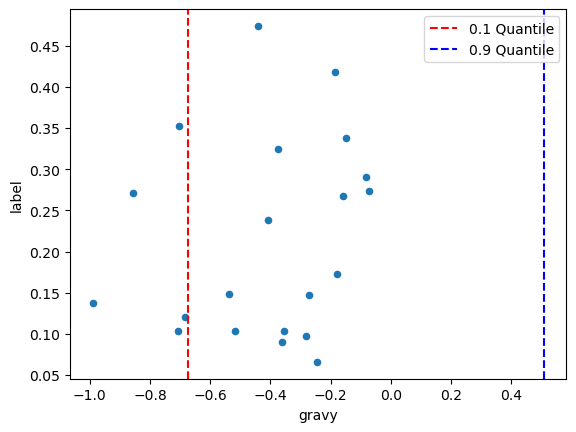

In [51]:
import matplotlib.pyplot as plt

def plot(name):
    features_df[[name, 'label']].plot.scatter(x=name, y='label')
    plt.axvline(x=q1[name], color='red', linestyle='--', label='0.1 Quantile')
    plt.axvline(x=q9[name], color='blue', linestyle='--', label='0.9 Quantile')
    plt.legend()

plot('gravy')

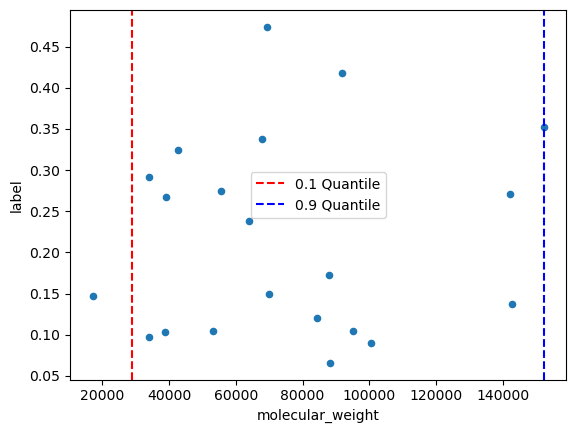

In [52]:
plot('molecular_weight')

In [56]:
mask = None
outlier_count=features_df.copy()
outlier_count['outlier'] = 0
for feature in ['molecular_weight',  'isoelectric_point', 'gravy']:
    new_mask = (q1[feature] < features_df[feature]) & (features_df[feature] < q9[feature])
    outlier_count['outlier'] += 1- new_mask.astype(int)
    if mask is None:
        mask = new_mask
    else:
        mask = mask | new_mask
outlier_count['outlier'] = outlier_count['outlier'] > 0

features_df[mask]['label'].mean(),features_df[mask]['label'].size 


(0.21604761904761904, 21)

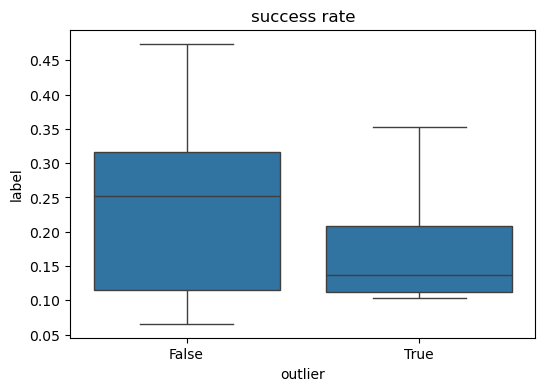

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example lists (replace with your own)
list_train = [1, 2, 3, 2, 1.5, 2.5, 2.2, 1.8]
list_test = [1, 2, 10, 2, 1.2, 0.5, 8.0, 2]

# Combine into a DataFrame for seaborn
# Create boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(data=outlier_count, x='outlier', y='label')
plt.title('success rate')
plt.show()

In [55]:
outlier_count['outlier'].value_counts()

0    14
1     4
2     3
Name: outlier, dtype: int64